# 04 - Preprocessing (Per-Fold Scaling)

**Goal:** Fit a sensor-input scaler on each fold's training rows only and persist the fitted artifact. Downstream models load the fold's scaler, transform train/val, then fit and evaluate.

**Approved decisions:**
- Scaler: `RobustScaler` (median / IQR) for `s01..s16`.
- Targets `methane_ppm`, `ethylene_ppm`: **no transformation** (metrics reported in original ppm units).
- Persist fitted scaler only (not preprocessed arrays).
- `time_s` excluded from features (sort-key only, per CLAUDE.md).
- No feature engineering in this notebook.

**Anti-leakage guarantee:** Each scaler is fit only on its fold's train slice from the frozen split artifact (`results/tables/validation_splits.parquet`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from sklearn.preprocessing import RobustScaler

SEED = 42

DATA_PATH    = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH  = Path('../results/tables/validation_splits.parquet')
PREPROC_DIR  = Path('../results/models/preprocessors')
FIG_DIR      = Path('../results/figures')
MEMO_PATH    = Path('../results/memos/04_preprocessing.md')

for d in (PREPROC_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']
TIME    = 'time_s'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})

## 1. Load Data & Frozen Splits

In [2]:
df = pd.read_parquet(DATA_PATH, columns=[TIME] + SENSORS + TARGETS)
print(f'Dataset rows: {len(df):,}, cols: {df.shape[1]}')

splits_df = pd.read_parquet(SPLITS_PATH)
n_folds = splits_df["fold"].nunique()
print(f'Splits artifact: {splits_df.shape[0]} rows, {n_folds} folds')

# Sanity: features and targets must already be clean (no silent imputation here).
assert df[SENSORS].notna().all().all(), 'NaN in sensor columns'
assert df[TARGETS].notna().all().all(), 'NaN in target columns'
assert np.isfinite(df[SENSORS].to_numpy()).all(), 'Non-finite values in sensor columns'
assert np.isfinite(df[TARGETS].to_numpy()).all(), 'Non-finite values in target columns'
print('Sanity checks passed: no NaN / inf in features or targets.')

Dataset rows: 4,178,504, cols: 19
Splits artifact: 10 rows, 5 folds
Sanity checks passed: no NaN / inf in features or targets.


## 2. Fit One Scaler Per Fold (Train Slice Only)

For every fold, fit `RobustScaler` on the **train** rows defined in the frozen split artifact, then persist the fitted scaler with its metadata. Val rows are NEVER touched here - they are only transformed at model-training time.

In [3]:
fold_records = []

for fold_id in sorted(splits_df['fold'].unique()):
    tr = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'train')].iloc[0]
    va = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'val')].iloc[0]

    X_train = df[SENSORS].iloc[tr['start_idx']:tr['end_idx']].to_numpy()

    scaler = RobustScaler()
    scaler.fit(X_train)

    artifact = {
        'fold': int(fold_id),
        'scaler': scaler,
        'feature_cols': SENSORS,
        'target_cols': TARGETS,
        'train_start_idx': int(tr['start_idx']),
        'train_end_idx':   int(tr['end_idx']),
        'val_start_idx':   int(va['start_idx']),
        'val_end_idx':     int(va['end_idx']),
        'n_train_rows':    int(tr['n_rows']),
        'n_val_rows':      int(va['n_rows']),
    }
    out_path = PREPROC_DIR / f'fold_{fold_id}.joblib'
    joblib.dump(artifact, out_path)

    fold_records.append({
        'fold':         int(fold_id),
        'n_train_rows': artifact['n_train_rows'],
        'n_val_rows':   artifact['n_val_rows'],
        'center_mean':  float(np.mean(scaler.center_)),
        'center_std':   float(np.std(scaler.center_)),
        'scale_mean':   float(np.mean(scaler.scale_)),
        'scale_std':    float(np.std(scaler.scale_)),
        'artifact':     out_path.as_posix(),
    })
    print(f'Fold {fold_id}: fit on {int(tr["n_rows"]):,} rows -> {out_path.name}')

fits_df = pd.DataFrame(fold_records)
print()
print('Per-fold scaler summary:')
print(fits_df.to_string(index=False))

Fold 1: fit on 1,664,421 rows -> fold_1.joblib
Fold 2: fit on 1,634,650 rows -> fold_2.joblib
Fold 3: fit on 1,641,557 rows -> fold_3.joblib
Fold 4: fit on 1,641,541 rows -> fold_4.joblib
Fold 5: fit on 1,671,616 rows -> fold_5.joblib

Per-fold scaler summary:
 fold  n_train_rows  n_val_rows  center_mean  center_std  scale_mean  scale_std                                      artifact
    1       1664421      407367  2446.632500  497.273296 1400.592500 717.893140 ../results/models/preprocessors/fold_1.joblib
    2       1634650      419449  2486.899062  522.200874 1574.442500 849.702850 ../results/models/preprocessors/fold_2.joblib
    3       1641557      407362  2351.793125  716.638830 1594.876250 836.558687 ../results/models/preprocessors/fold_3.joblib
    4       1641541      431972  2512.590000  519.667484 1602.379375 858.790893 ../results/models/preprocessors/fold_4.joblib
    5       1671616      435098  2286.672500  755.197190 1614.088125 819.889364 ../results/models/preprocesso

## 3. Verification

Reload each saved scaler and verify:
- Transforming the train slice yields finite values.
- Transforming the val slice yields finite values (even though val distribution differs from train).
- Scaler statistics genuinely differ across folds (i.e., we are not accidentally reusing the same fit).

In [4]:
loaded_centers = []
for fold_id in sorted(splits_df['fold'].unique()):
    art = joblib.load(PREPROC_DIR / f'fold_{fold_id}.joblib')
    scaler = art['scaler']

    X_tr = df[SENSORS].iloc[art['train_start_idx']:art['train_end_idx']].to_numpy()
    X_va = df[SENSORS].iloc[art['val_start_idx']:art['val_end_idx']].to_numpy()
    Xt_tr = scaler.transform(X_tr)
    Xt_va = scaler.transform(X_va)
    assert np.isfinite(Xt_tr).all(), f'Non-finite values in transformed train for fold {fold_id}'
    assert np.isfinite(Xt_va).all(), f'Non-finite values in transformed val for fold {fold_id}'
    loaded_centers.append(scaler.center_.copy())
    print(f'Fold {fold_id}: train_shape={Xt_tr.shape}, val_shape={Xt_va.shape}, all finite OK')

centers = np.vstack(loaded_centers)
pairwise_max_diff = max(
    float(np.max(np.abs(centers[i] - centers[j])))
    for i in range(len(centers)) for j in range(i + 1, len(centers))
)
print()
print(f'Max abs difference between any two fold centers: {pairwise_max_diff:.6g}')
assert pairwise_max_diff > 0, 'All fold centers identical - scaler appears to be fit on the same data'
print('All folds have distinct scaler statistics.')

Fold 1: train_shape=(1664421, 16), val_shape=(407367, 16), all finite OK
Fold 2: train_shape=(1634650, 16), val_shape=(419449, 16), all finite OK
Fold 3: train_shape=(1641557, 16), val_shape=(407362, 16), all finite OK
Fold 4: train_shape=(1641541, 16), val_shape=(431972, 16), all finite OK
Fold 5: train_shape=(1671616, 16), val_shape=(435098, 16), all finite OK

Max abs difference between any two fold centers: 1540.35
All folds have distinct scaler statistics.


## 4. Before / After Distribution (Fold 1, Spot Check)

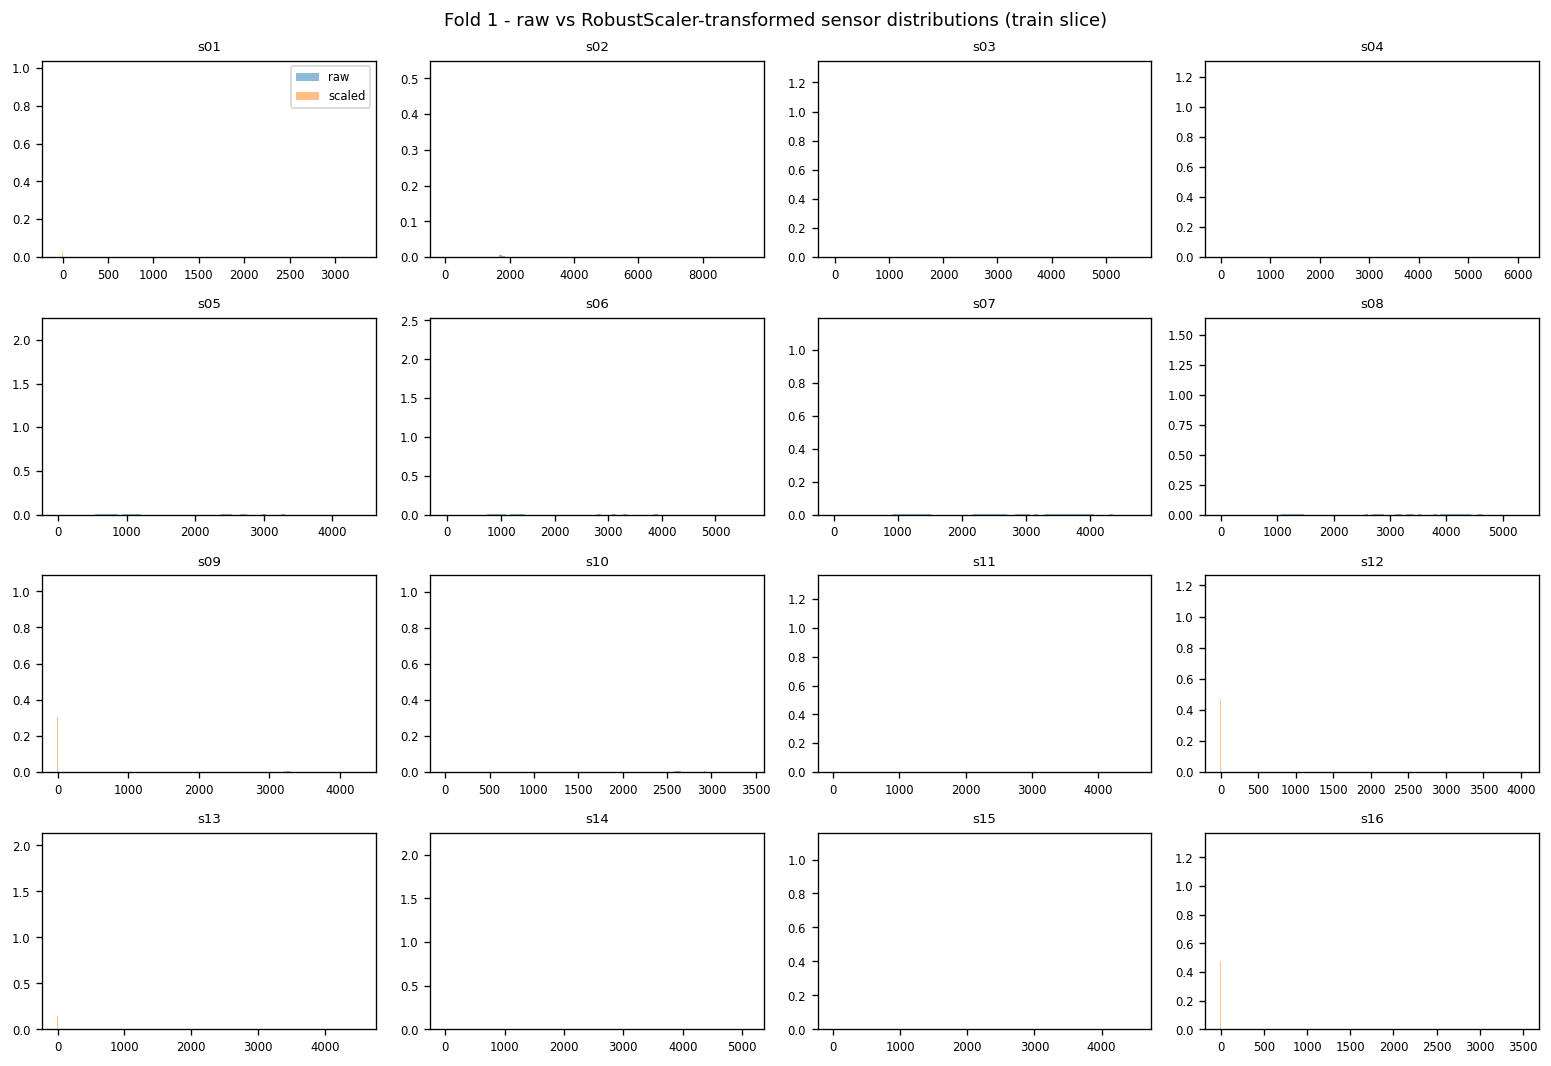

Saved: 04_fold1_scaling.png


In [5]:
art = joblib.load(PREPROC_DIR / 'fold_1.joblib')
X_tr  = df[SENSORS].iloc[art['train_start_idx']:art['train_end_idx']].to_numpy()
Xt_tr = art['scaler'].transform(X_tr)

fig, axes = plt.subplots(4, 4, figsize=(13, 9))
for i, ax in enumerate(axes.flat):
    ax.hist(X_tr[:, i],  bins=80, alpha=0.5, label='raw',    density=True)
    ax.hist(Xt_tr[:, i], bins=80, alpha=0.5, label='scaled', density=True)
    ax.set_title(SENSORS[i], fontsize=8)
    ax.tick_params(labelsize=7)
    if i == 0:
        ax.legend(fontsize=7)
fig.suptitle('Fold 1 - raw vs RobustScaler-transformed sensor distributions (train slice)')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_fold1_scaling.png', bbox_inches='tight')
plt.show()
print('Saved: 04_fold1_scaling.png')

## 5. Save Memo

In [6]:
def df_to_md(t):
    header = '| ' + ' | '.join(t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |'
              for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

summary_md = df_to_md(fits_df[['fold', 'n_train_rows', 'n_val_rows',
                               'center_mean', 'center_std',
                               'scale_mean',  'scale_std']].round(4))

lines = [
    '# 04 - Preprocessing (Per-Fold Scaling)',
    '',
    '**Date:** 2026-05-19',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Scaler artifacts:** {PREPROC_DIR.as_posix()}/fold_{{1..5}}.joblib',
    '',
    '---',
    '',
    '## Decisions (all user-approved)',
    '- Input scaler: `RobustScaler` (median / IQR) applied to `s01..s16`.',
    '- Targets `methane_ppm`, `ethylene_ppm`: no transformation.',
    '- One fitted scaler persisted per fold; preprocessed arrays NOT cached.',
    '- `time_s` excluded from features.',
    '- No feature engineering in this notebook.',
    '',
    '## Anti-leakage',
    '- Each scaler fit only on the train slice of its fold.',
    '- Verification reloaded every scaler, transformed train and val slices, asserted finite values.',
    '- Pairwise scaler-center differences across folds are non-zero (folds genuinely distinct).',
    '',
    '## Per-Fold Scaler Summary',
    '',
    summary_md,
    '',
    '## Usage',
    '',
    '```python',
    'import joblib',
    'art = joblib.load("results/models/preprocessors/fold_1.joblib")',
    'scaler = art["scaler"]',
    'X_train  = df[art["feature_cols"]].iloc[art["train_start_idx"]:art["train_end_idx"]].to_numpy()',
    'X_val    = df[art["feature_cols"]].iloc[art["val_start_idx"]:art["val_end_idx"]].to_numpy()',
    'Xt_train = scaler.transform(X_train)',
    'Xt_val   = scaler.transform(X_val)',
    '# Targets used in raw ppm:',
    'y_train  = df[art["target_cols"]].iloc[art["train_start_idx"]:art["train_end_idx"]].to_numpy()',
    'y_val    = df[art["target_cols"]].iloc[art["val_start_idx"]:art["val_end_idx"]].to_numpy()',
    '```',
    '',
    '## Next Step',
    '',
    'Notebook `05_baselines.ipynb` (pending approval): train baseline models per fold using these scalers, evaluate with the same metrics across all folds.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\04_preprocessing.md
